In [1]:
# Import neccessary libraries and modules

import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

## Fetching Data

Dataset: **Immigration to Canada from 1980 to 2013 - International migration flows to and from selected countries - The 2015 revision from United Nation's website**


In [2]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')

print('Dataframe is imported successfully !!!')

print(df.shape)
df.head()

Dataframe is imported successfully !!!
(195, 39)


,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


In [3]:
# Set 'Country' as the index to lookup data more easily
df.set_index('Country', inplace=True)

# Verify the index
df.head()

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15


In [4]:
# List of years
years = list(map(str, range(1980, 2014)))

years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

## Area Plot

In the last module, we created a **line plot** that visualized the **top 5 countries** that contribued the most immigrants to Canada from 1980 to 2013. With a little modification to the code, we can visualize this plot as a **cumulative plot**, also knows as a **Stacked Line Plot** or **Area plot**.

In [5]:
df.sort_values(['Total'], ascending=False, axis=0, inplace=True)

# Get the top 5 countries
df_top_5 = df.head()

# Transpose the dataframe
df_top_5 = df_top_5[years].transpose()

df_top_5.head()

Country,India,China,United Kingdom of Great Britain and Northern Ireland,Philippines,Pakistan
1980,8880,5123,22045,6051,978
1981,8670,6682,24796,5921,972
1982,8147,3308,20620,5249,1201
1983,7338,1863,10015,4562,900
1984,5704,1527,10170,3801,668


Area plots are stacked by default. And to produce a stacked area plot, each column must be either all positive or all negative values (any NaN, i.e. not a number, values will default to 0). To produce an unstacked plot, set parameter stacked to value False.

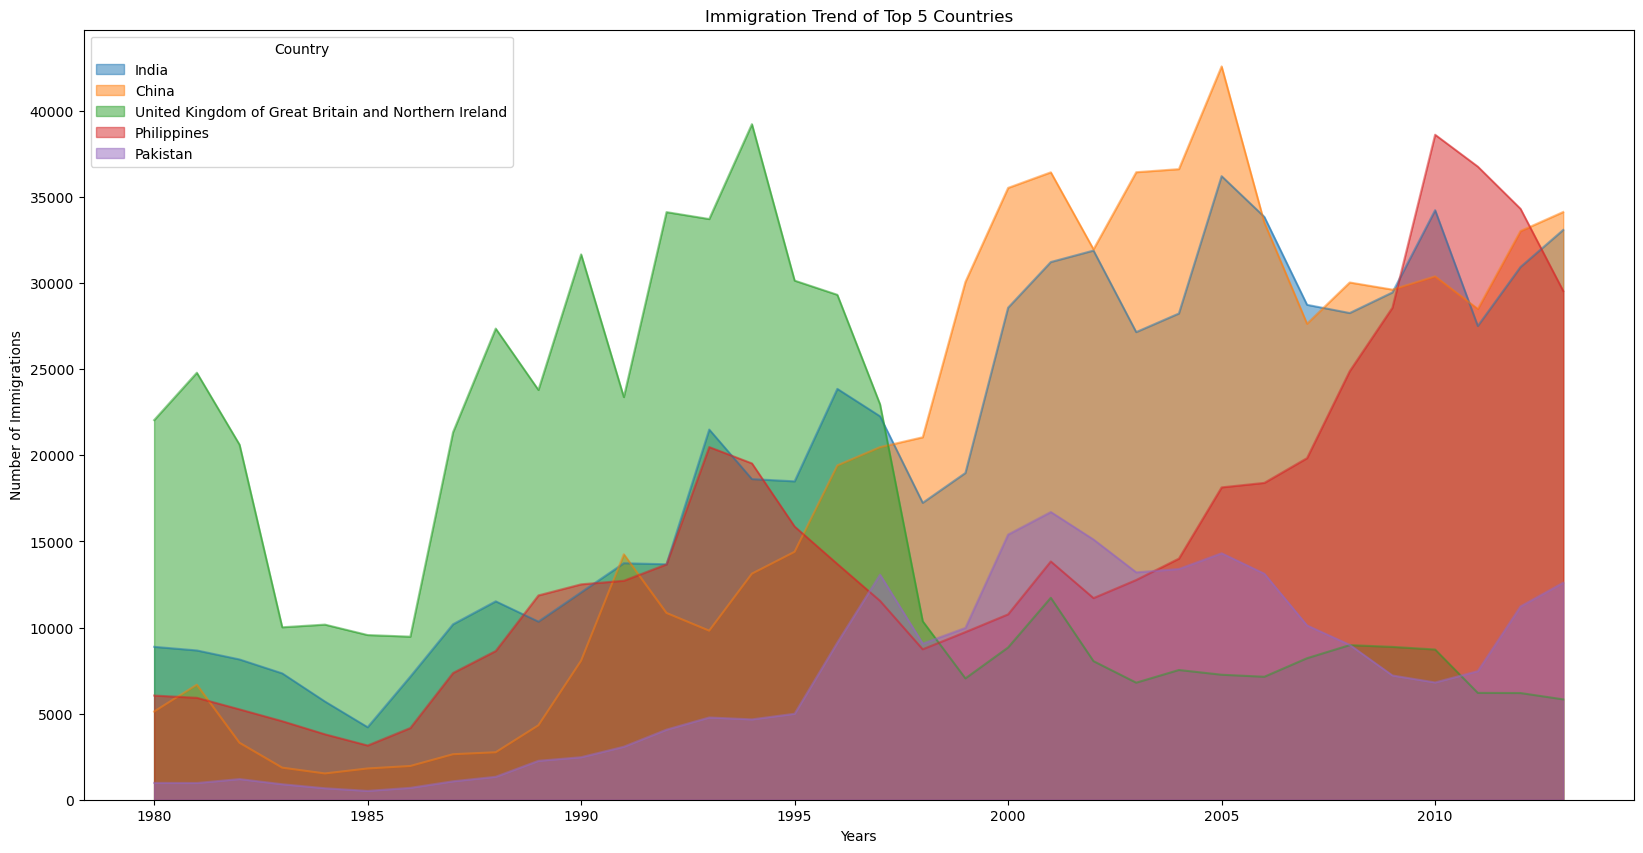

In [6]:
df_top_5.index = df_top_5.index.map(int)

df_top_5.plot(kind='area', stacked=False, figsize=(20, 10))

plt.title('Immigration Trend of Top 5 Countries')
plt.xlabel('Years')
plt.ylabel('Number of Immigrations')

plt.show()

The unstacked plot has a default transparency (alpha value) at 0.5. We can modify this value by passing in the alpha parameter.

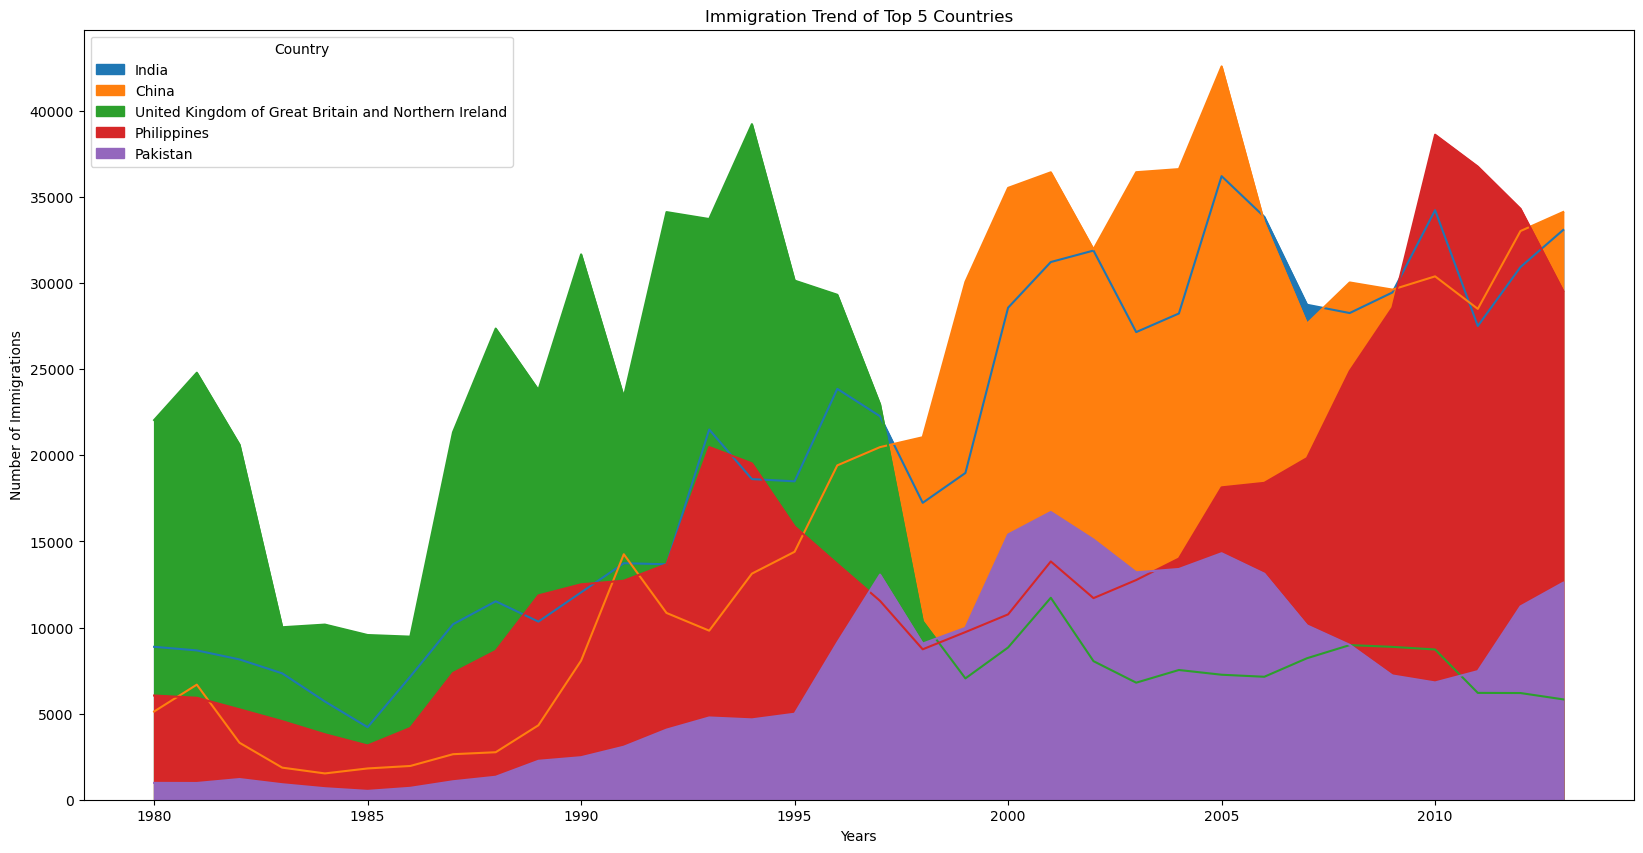

In [7]:
df_top_5.plot(kind='area', alpha=1, stacked=False, figsize=(20, 10))

plt.title('Immigration Trend of Top 5 Countries')
plt.xlabel('Years')
plt.ylabel('Number of Immigrations')

plt.show()

## Two types of plotting
As we discussed in the video lectures, there are two styles/options of plotting with matplotlib， plotting using the **Artist layer** and plotting using the **scripting layer**.

### Option 1: Scripting layer (procedural method) - using matplotlib.pyplot as 'plt'

You can use plt i.e. matplotlib.pyplot and add more elements by calling different methods procedurally; for example, plt.title(...) to add title or plt.xlabel(...) to add label to the x-axis.

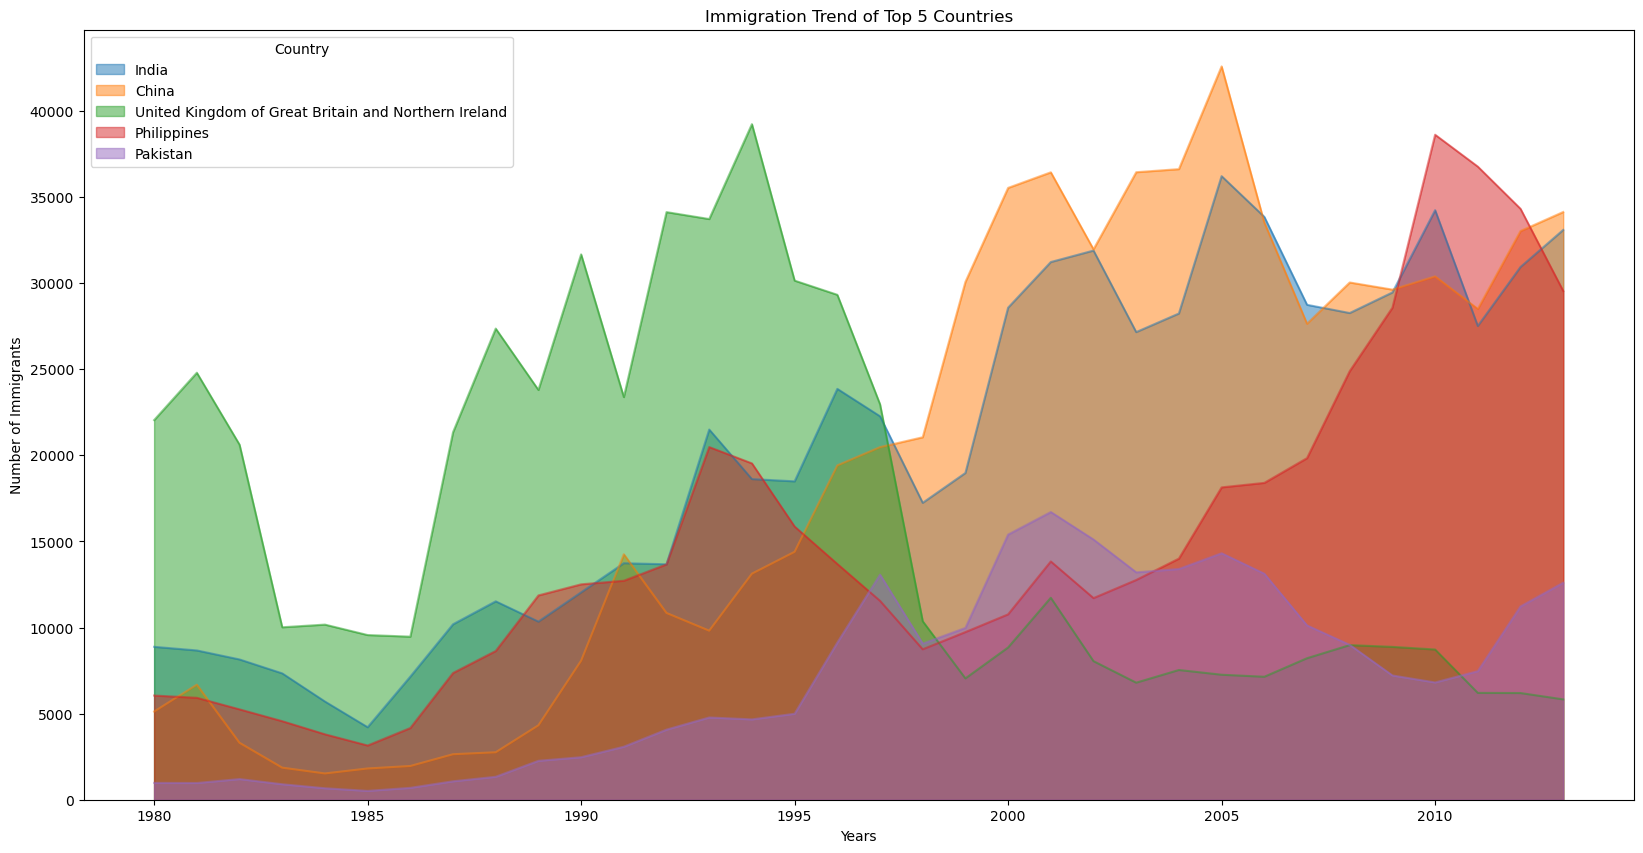

In [8]:
df_top_5.plot(kind='area', alpha=0.5, stacked=False, figsize=(20, 10))

plt.title('Immigration Trend of Top 5 Countries')
plt.xlabel('Years')
plt.ylabel('Number of Immigrants')

plt.show()

### Option 2: Artist layer (Object oriented method) - using an Axes instance from Matplotlib (preferred)

You can use an Axes instance of your current plot and store it in a variable (eg. ax). You can add more elements by calling methods with a little change in syntax (by adding "set_" to the previous methods). For example, use ax.set_title() instead of plt.title() to add title, or ax.set_xlabel() instead of plt.xlabel() to add label to the x-axis.

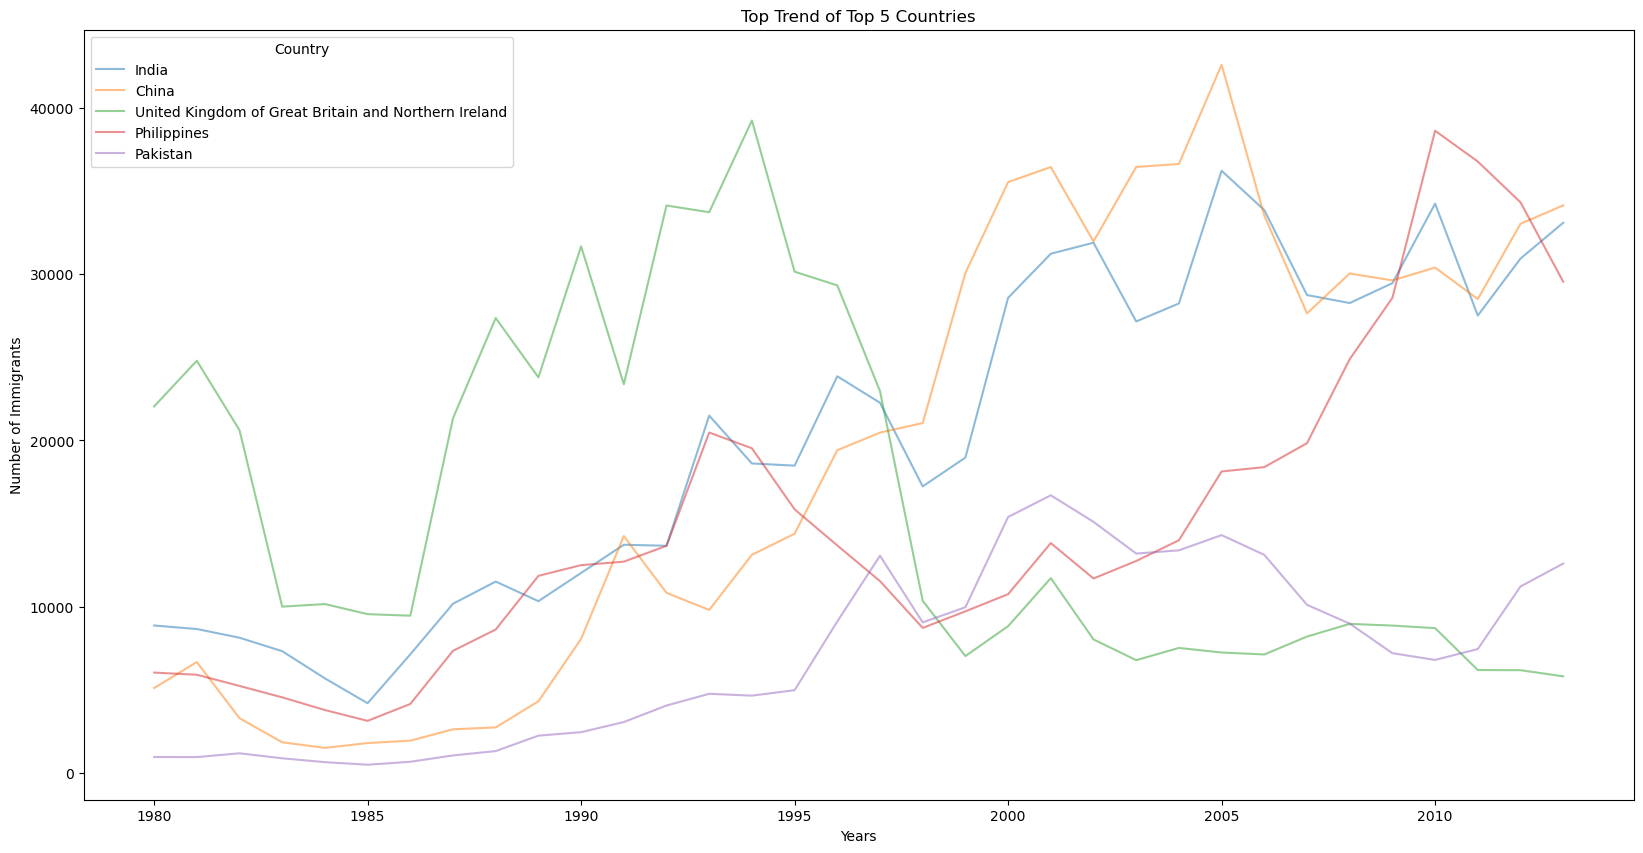

In [9]:
ax = df_top_5.plot(kind='line', alpha=0.5, figsize= (20, 10))

ax.set_title('Top Trend of Top 5 Countries')
ax.set_xlabel('Years')
ax.set_ylabel('Number of Immigrants')

plt.show()

### Practice: Use 2 types of layer to create a stacked area plot of the 5 countries that contributed the least to immigration to Canada from 1980 to 2013.

**Prepare the dataframe**

In [10]:
df_least_5 = df.tail(5)

df_least_5 = df_least_5[years].transpose()
df_least_5.index = df_least_5.index.map(int)

**Scripting layer**

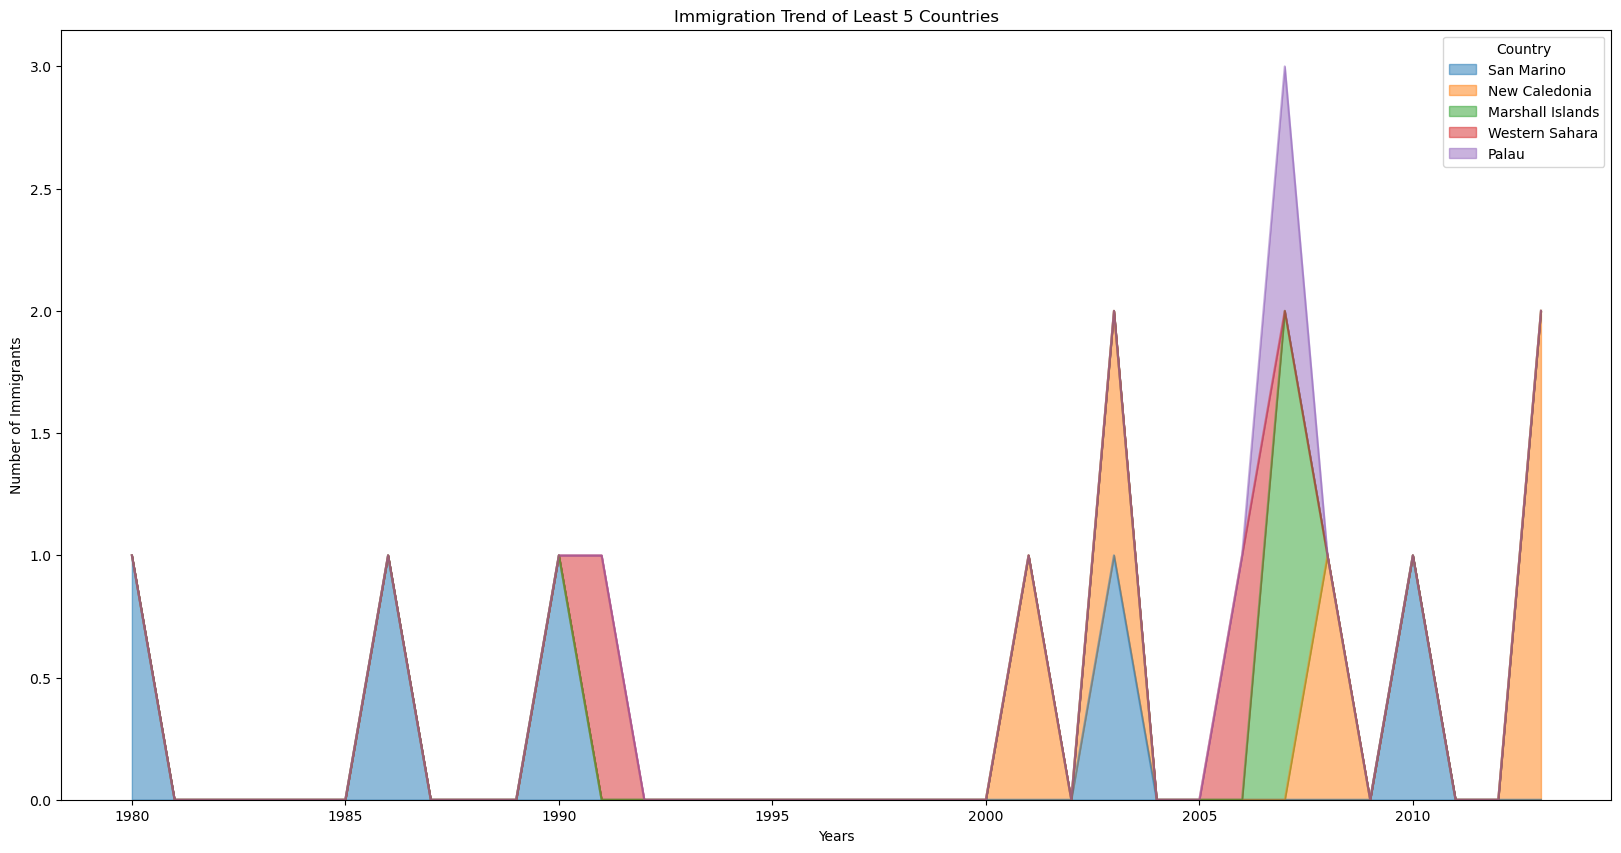

In [11]:
df_least_5.plot(kind='area', alpha=0.5, figsize=(20, 10))

plt.title('Immigration Trend of Least 5 Countries')
plt.xlabel('Years')
plt.ylabel('Number of Immigrants')

plt.show()

**Artist layer**

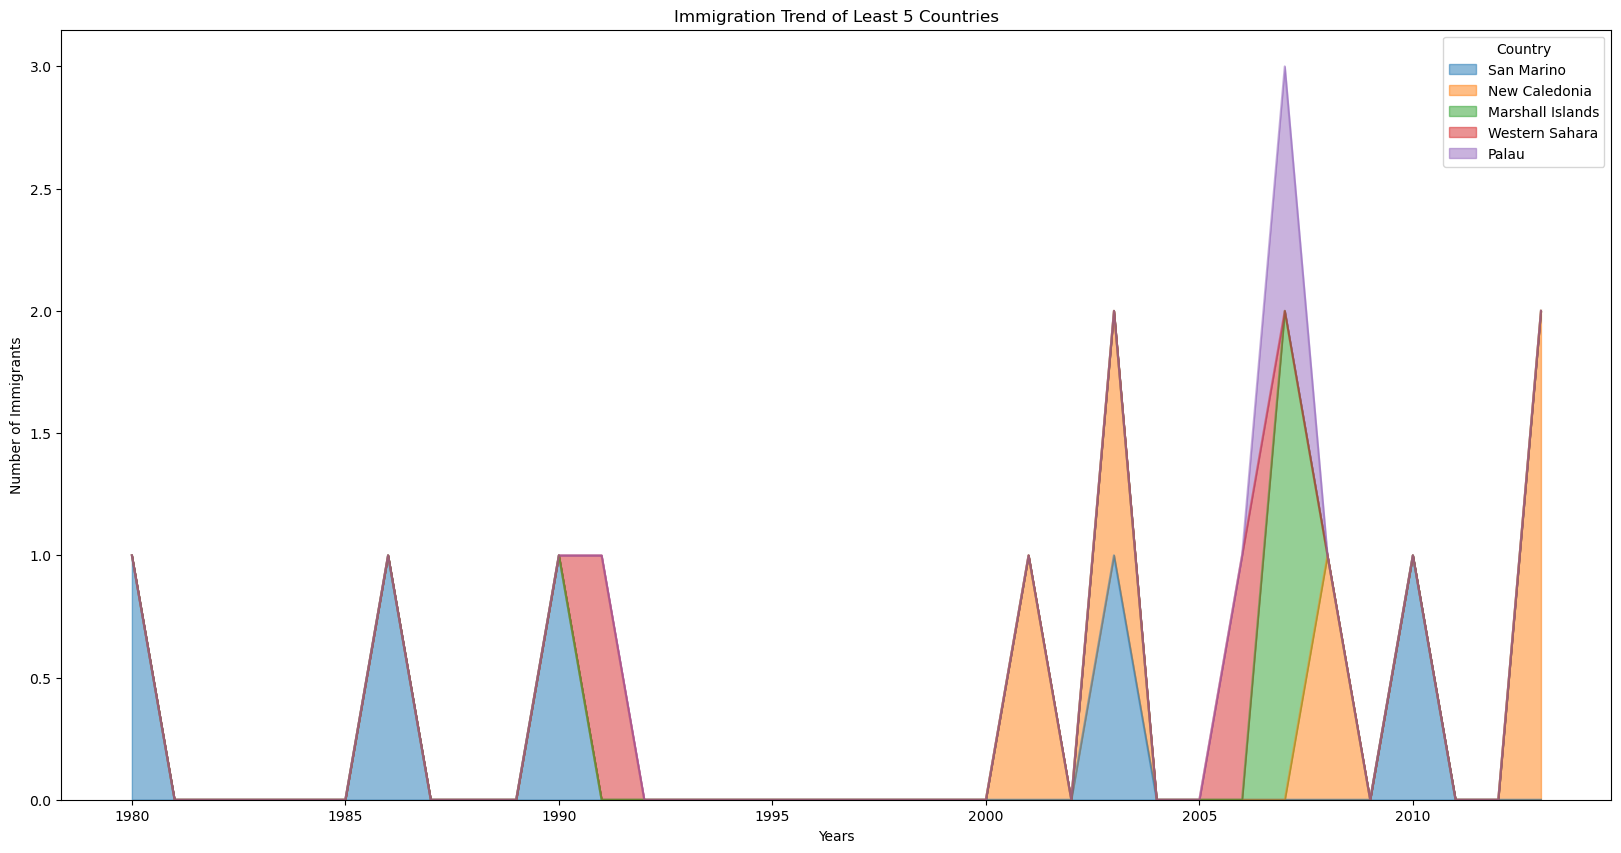

In [12]:
ax = df_least_5.plot(kind='area', alpha=0.5, figsize=(20, 10))

ax.set_xlabel('Years')
ax.set_ylabel('Number of Immigrants')
ax.set_title('Immigration Trend of Least 5 Countries')

plt.show()

## Histograms

A histogram is a way of representing the frequency distribution of numeric dataset. The way it works is it partitions the x-axis into bins, assigns each data point in our dataset to a bin, and then counts the number of data points that have been assigned to each bin. So the y-axis is the frequency or the number of data points in each bin. Note that we can change the bin size and usually one needs to tweak it so that the distribution is displayed nicely.

In [13]:
# Let's view the 2013 data
df['2013'].head()

# np.histogram returns 2 values
count, bin = np.histogram(df['2013'])
print('Count: ', count)
print('Bin: ', bin)

Count:  [178  11   1   2   0   0   0   0   1   2]
Bin:  [    0.   3412.9  6825.8 10238.7 13651.6 17064.5 20477.4 23890.3 27303.2
 30716.1 34129. ]


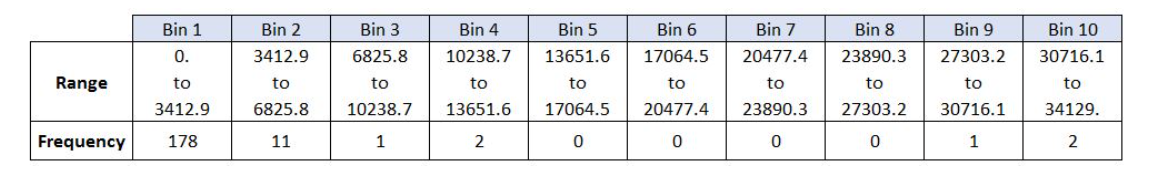

We can easily graph this distribution by passing **kind=hist** to **plot()**.

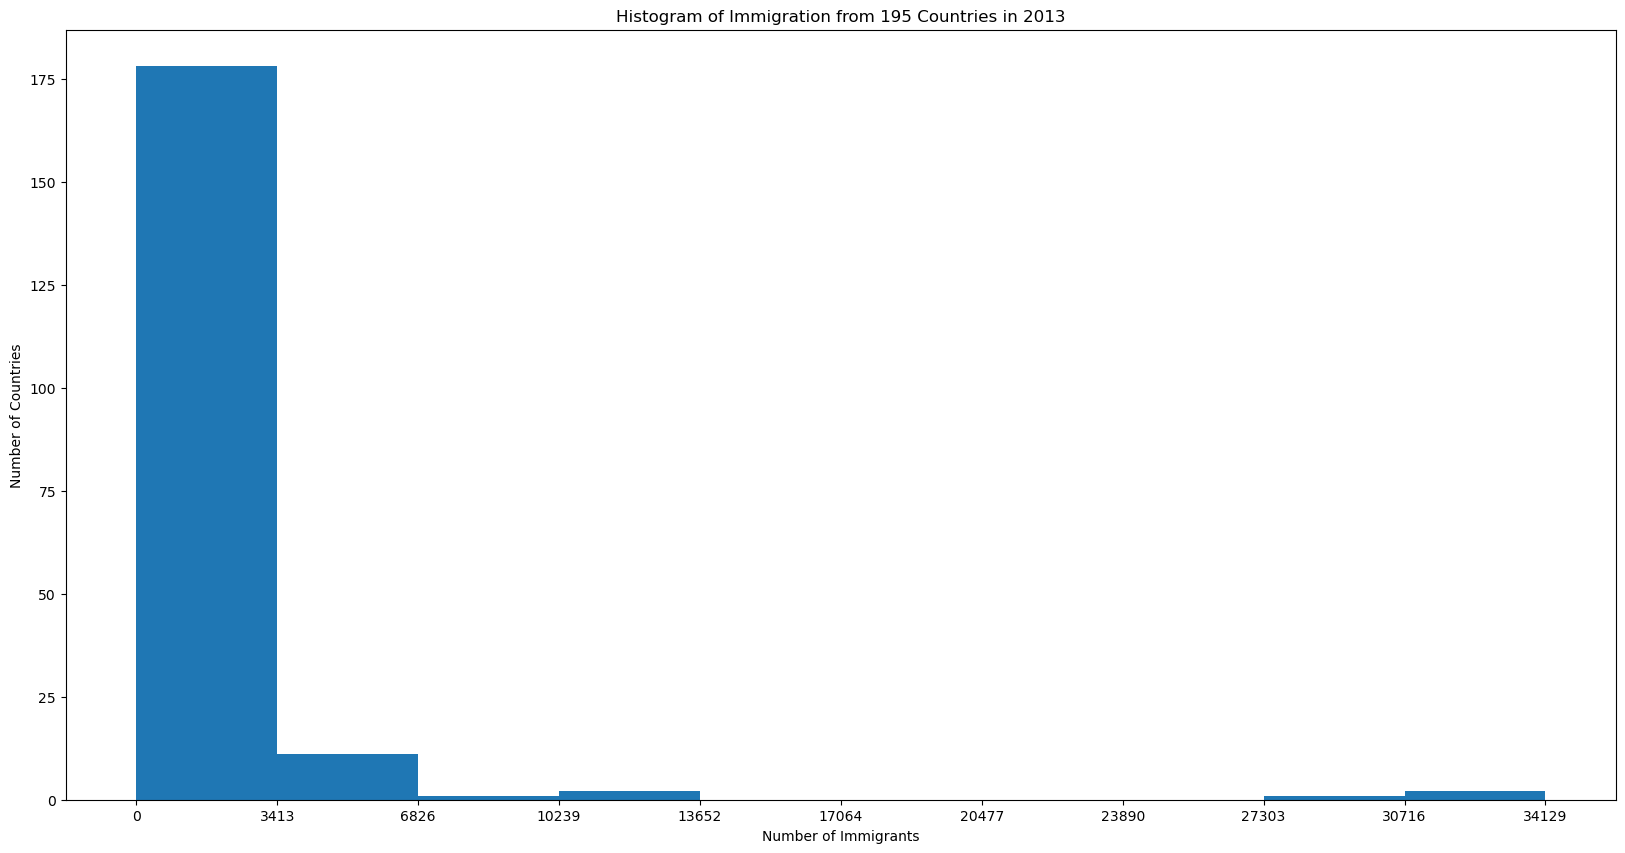

In [14]:
# xticks to give values on the x-axis
df['2013'].plot(kind='hist', figsize=(20, 10), xticks=bin)

plt.title('Histogram of Immigration from 195 Countries in 2013')
plt.xlabel('Number of Immigrants')
plt.ylabel('Number of Countries')

plt.show()

### Practice question: What is the immigration distribution for Denmark, Norway, and Sweden for years 1980 - 2013?

In [15]:
# let's quickly view the dataset 
df.loc[['Denmark', 'Norway', 'Sweden'], years]

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
Denmark,272,293,299,106,93,73,93,109,129,129,...,89,62,101,97,108,81,92,93,94,81
Norway,116,77,106,51,31,54,56,80,73,76,...,73,57,53,73,66,75,46,49,53,59
Sweden,281,308,222,176,128,158,187,198,171,182,...,129,205,139,193,165,167,159,134,140,140


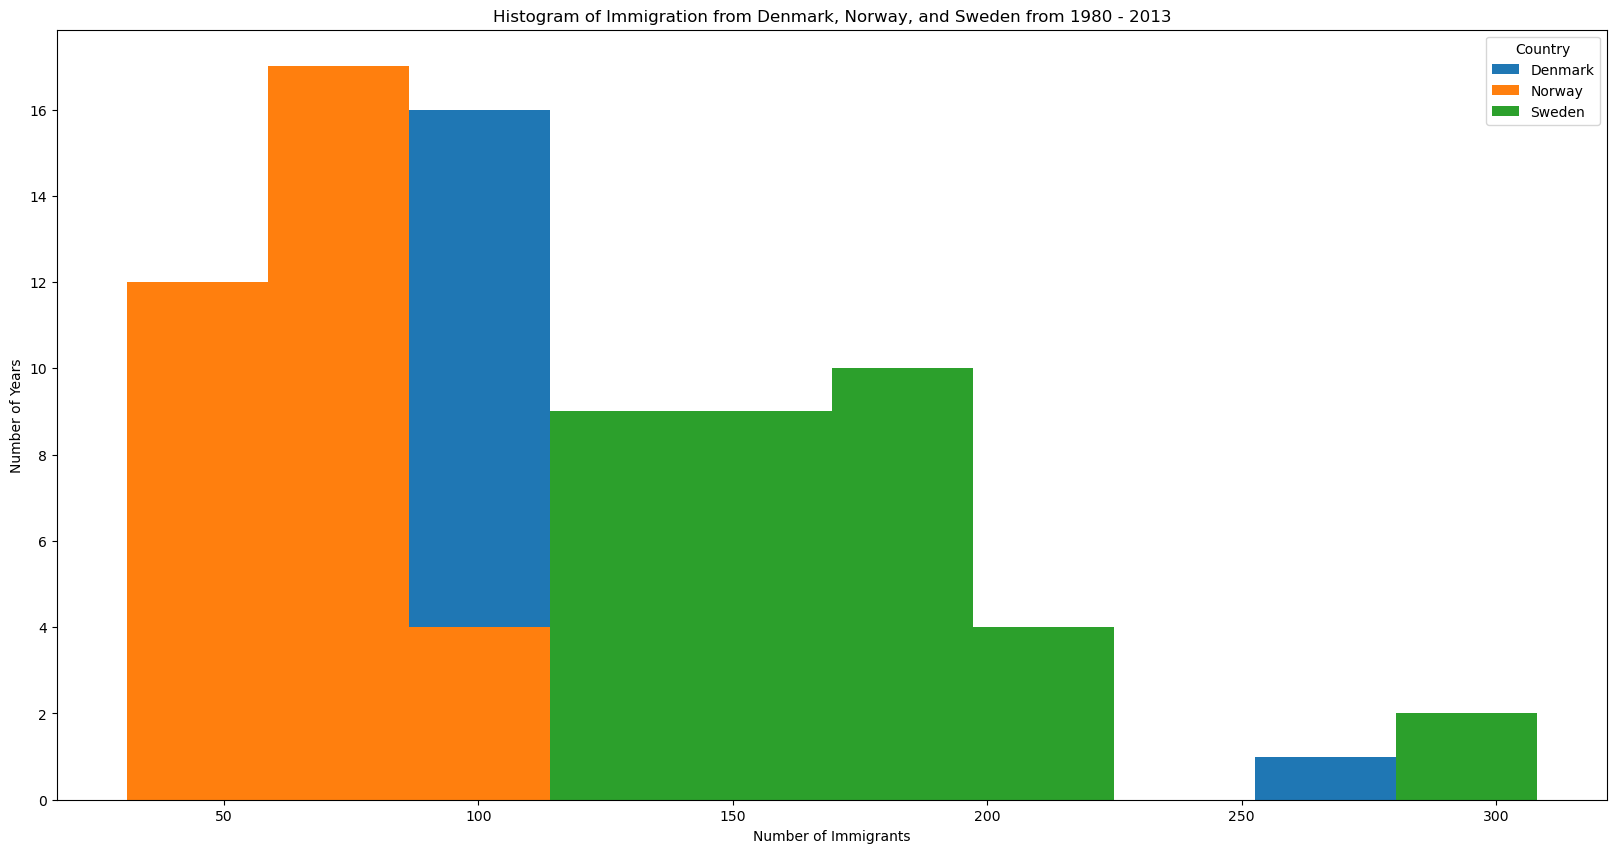

In [16]:
df_3_countries = df.loc[['Denmark', 'Norway', 'Sweden'], years].transpose()

df_3_countries.plot(kind='hist', figsize=(20, 10))

plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')

plt.show()

Let's make a few modifications to improve the impact and aesthetics of the previous plot:
<ul>
    <li>increase the bin size to 15 by passing in bins parameter;</li>
    <li>set transparency to 60% by passing in alpha parameter;</li>
    <li>label the x-axis by passing in x-label parameter;</li>
    <li>change the colors of the plots by passing in color parameter.</li>
</ul>

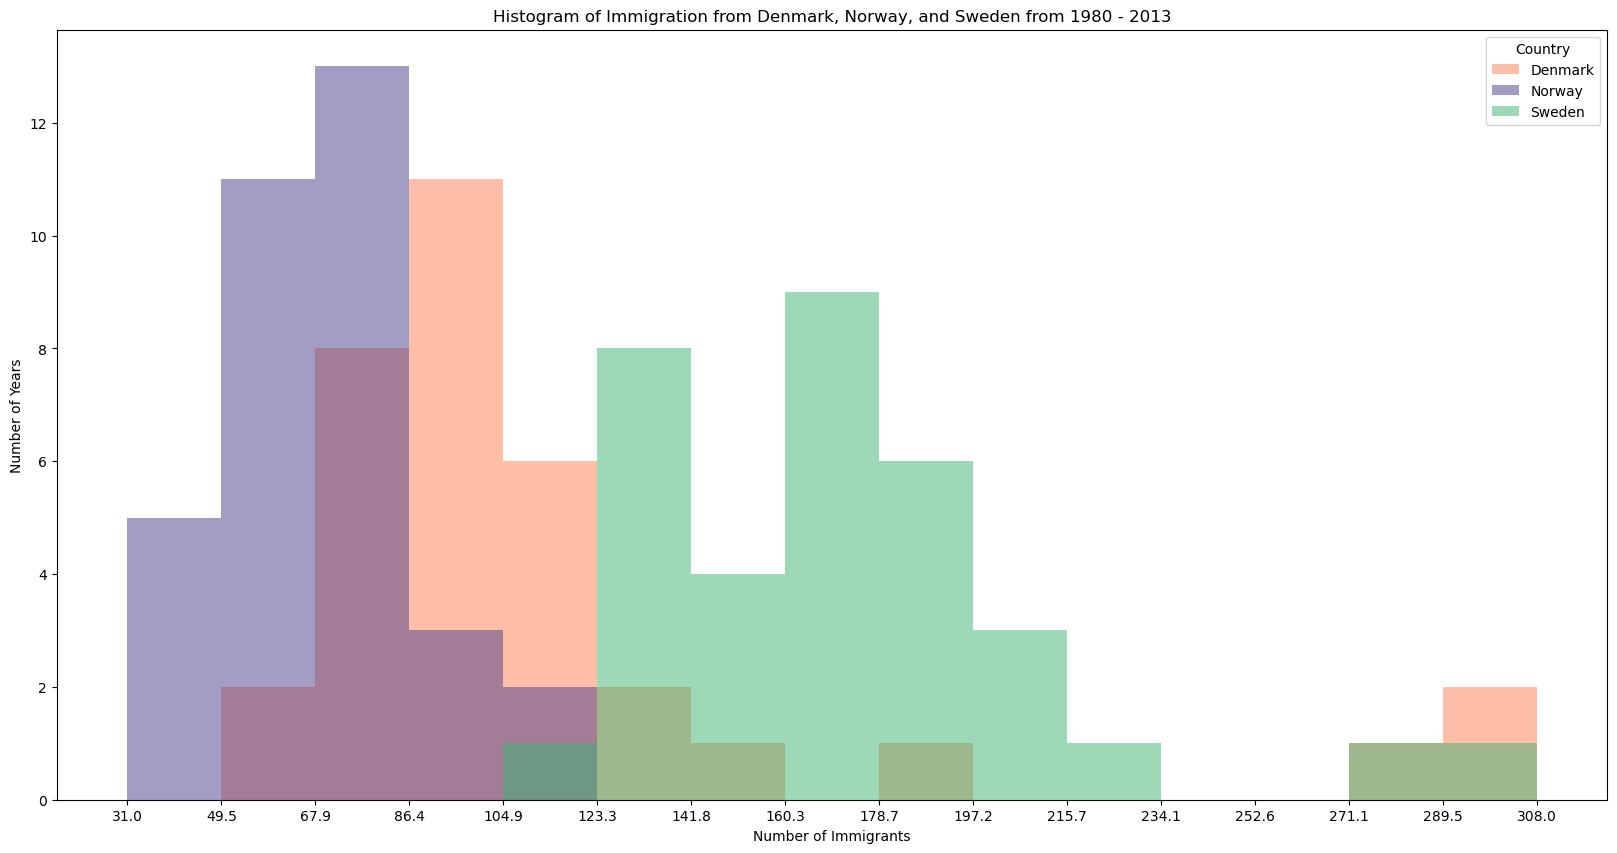

In [17]:
# Let's get the x-ticks value
count, bin = np.histogram(df_3_countries, 15)

# Unstacked histogram
df_3_countries.plot(kind='hist', 
                    figsize=(20, 10), 
                    bins=15, xticks=bin, 
                    alpha=0.5, 
                    color=['coral', 'darkslateblue', 'mediumseagreen'])

plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.xlabel('Number of Immigrants')
plt.ylabel('Number of Years')

plt.show()

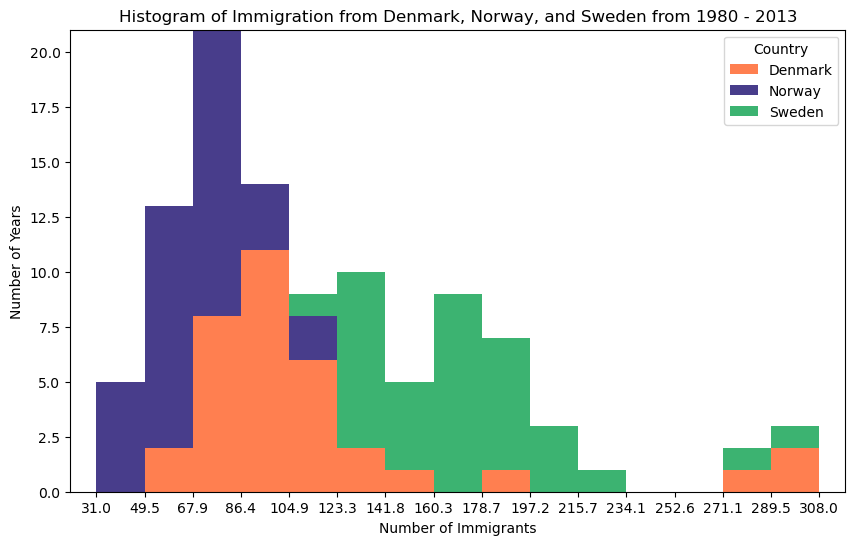

In [18]:
count, bin = np.histogram(df_3_countries, 15)
xmin = bin[0] - 10   #  first bin value is 31.0, adding buffer of 10 for aesthetic purposes 
xmax = bin[-1] + 10  #  last bin value is 308.0, adding buffer of 10 for aesthetic purposes

# stacked Histogram
df_3_countries.plot(kind='hist',
          figsize=(10, 6), 
          bins=15,
          xticks=bin,
          color=['coral', 'darkslateblue', 'mediumseagreen'],
          stacked=True,
          xlim=(xmin, xmax)
         )

plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants') 

plt.show()

### Practice question: Use the scripting layer to display the immigration distribution for Greece, Albania, and Bulgaria for years 1980 - 2013? Use an overlapping plot with 15 bins and a transparency value of 0.35.

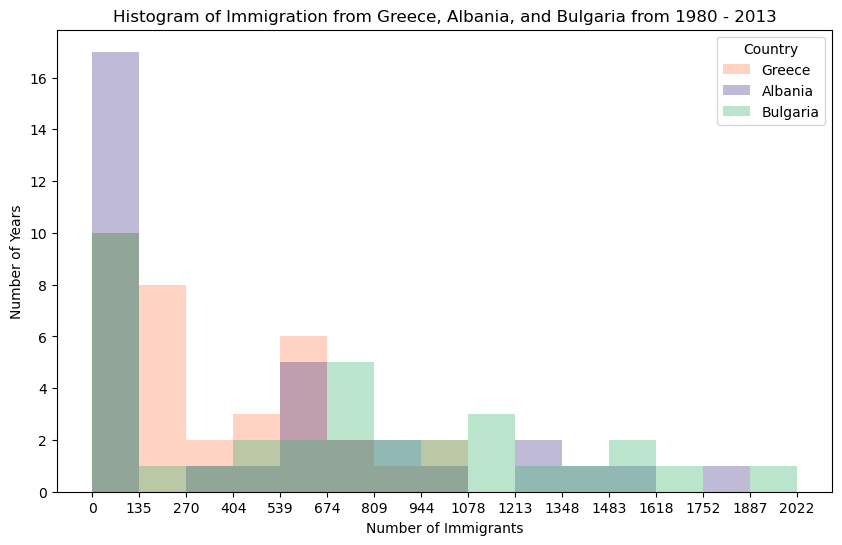

In [19]:
# Create a dataframe of the countries of interest (cof)
df_3_countries = df.loc[['Greece', 'Albania', 'Bulgaria'], years]

# Transpose the dataframe
df_3_countries = df_3_countries.transpose() 

# Let's get the x-tick values
count, bin_edges = np.histogram(df_3_countries, 15)

# Un-stacked Histogram
df_3_countries.plot(kind ='hist',
            figsize=(10, 6),
            bins=15,
            alpha=0.35,
            xticks=bin_edges,
            color=['coral', 'darkslateblue', 'mediumseagreen']
            )

plt.title('Histogram of Immigration from Greece, Albania, and Bulgaria from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')

plt.show()


## Bar Charts (Dataframe) 
A bar plot is a way of representing data where the length of the bars represents the magnitude/size of the feature/variable. Bar graphs usually represent numerical and categorical variables grouped in intervals.

To create a bar plot, we can pass one of two arguments via kind parameter in plot():

**kind=bar** creates a vertical bar plot <br>
**kind=barh** creates a horizontal bar plot

### Vertical bar plot

**Practice question: Let's compare the number of Icelandic immigrants (country = 'Iceland') to Canada from year 1980 to 2013.**

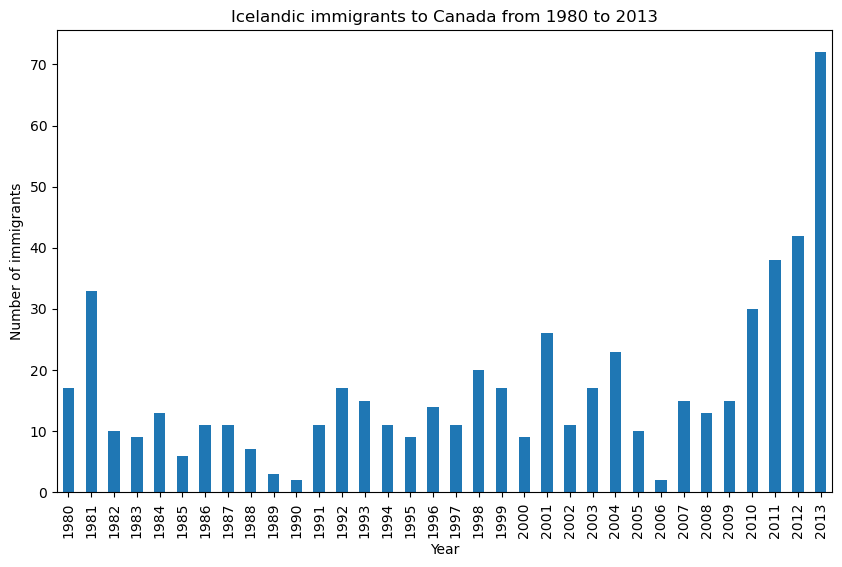

In [20]:
# Get the data
df_iceland = df.loc['Iceland', years]

# Plot the data
df_iceland.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Year') # add to x-label to the plot
plt.ylabel('Number of immigrants') # add y-label to the plot
plt.title('Icelandic immigrants to Canada from 1980 to 2013') # add title to the plot

plt.show()

Let's annotate this on the plot using the annotate method of the scripting layer or the pyplot interface. We will pass in the following parameters:

<ul>
    <li>s: str, the text of annotation.</li>
    <li>xy: Tuple specifying the (x,y) point to annotate (in this case, end point of arrow).</li>
    <li>xytext: Tuple specifying the (x,y) point to place the text (in this case, start point of arrow).</li>
    <li>xycoords: The coordinate system that xy is given in - 'data' uses the coordinate system of the object being annotated (default).</li>
    <li>arrowprops: Takes a dictionary of properties to draw the arrow:</li>
    <li>arrowstyle: Specifies the arrow style, '->' is standard arrow.</li>
    <li>connectionstyle: Specifies the connection type. arc3 is a straight line.</li>
    <li>color: Specifies color of arrow.</li>
    <li>lw: Specifies the line width.</li>
</ul>

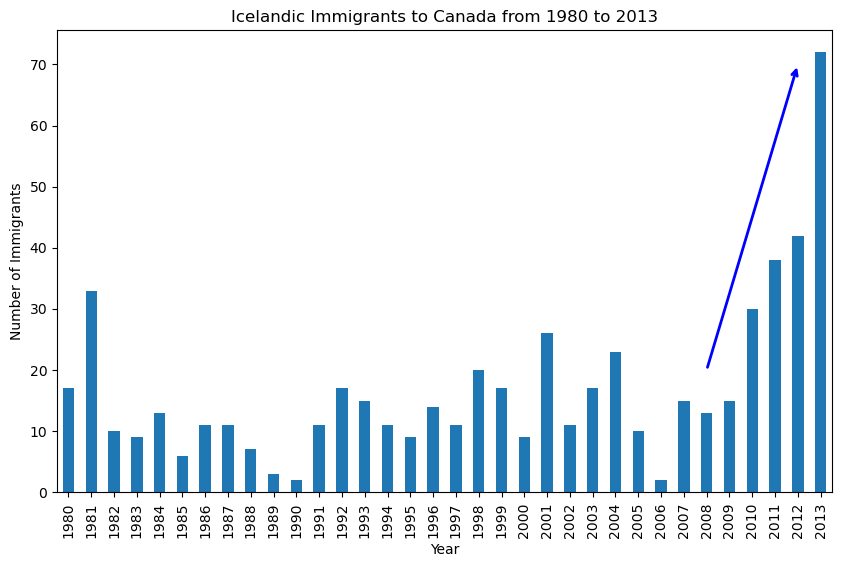

In [21]:
df_iceland.plot(kind='bar', figsize=(10, 6), rot=90)  # rotate the xticks(labelled points on x-axis) by 90 degrees

plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.title('Icelandic Immigrants to Canada from 1980 to 2013')

# Annotate arrow
plt.annotate('',  # s: str. Will leave it blank for no text
             xy=(32, 70),  # place head of the arrow at point (year 2012 , pop 70)
             xytext=(28, 20),  # place base of the arrow at point (year 2008 , pop 20)
             xycoords='data',  # will use the coordinate system of the object being annotated
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2)
             )

plt.show()

Let's also annotate a text to go over the arrow. We will pass in the following additional parameters:

<ul>
    <li>rotation: rotation angle of text in degrees (counter clockwise)</li>
    <li>va: vertical alignment of text [‘center’ | ‘top’ | ‘bottom’ | ‘baseline’]</li>
    <li>ha: horizontal alignment of text [‘center’ | ‘right’ | ‘left’]</li>
</ul>

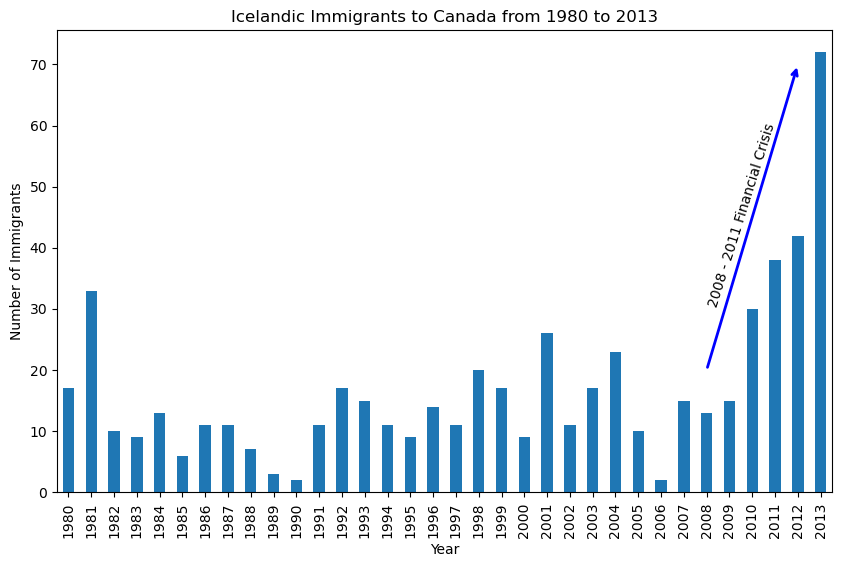

In [22]:
df_iceland.plot(kind='bar', figsize=(10, 6), rot=90)

plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.title('Icelandic Immigrants to Canada from 1980 to 2013')

# Annotate arrow
plt.annotate('',  # s: str. will leave it blank for no text
             xy=(32, 70),  # place head of the arrow at point (year 2012 , pop 70)
             xytext=(28, 20),  # place base of the arrow at point (year 2008 , pop 20)
             xycoords='data',  # will use the coordinate system of the object being annotated
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2)
             )

# Annotate Text
plt.annotate('2008 - 2011 Financial Crisis',  # text to display
             xy=(28, 30),  # start the text at at point (year 2008 , pop 30)
             rotation=72.5,  # based on trial and error to match the arrow
             va='bottom',  # want the text to be vertically 'bottom' aligned
             ha='left',  # want the text to be horizontally 'left' algned.
             )

plt.show()

### Horizontal Bar Plot

Sometimes it is more practical to represent the data horizontally, especially if you need more room for labelling the bars. In horizontal bar graphs, the y-axis is used for labelling, and the length of bars on the x-axis corresponds to the magnitude of the variable being measured. As you will see, there is more room on the y-axis to label categorical variables.

In [23]:
# sort dataframe on 'Total' column (descending)
df.sort_values(by='Total', ascending=True, inplace=True)

# get top 15 countries
df_top15 = df['Total'].tail(15)
df_top15

Country
Romania                                                  93585
Viet Nam                                                 97146
Jamaica                                                 106431
France                                                  109091
Lebanon                                                 115359
Poland                                                  139241
Republic of Korea                                       142581
Sri Lanka                                               148358
Iran (Islamic Republic of)                              175923
United States of America                                241122
Pakistan                                                241600
Philippines                                             511391
United Kingdom of Great Britain and Northern Ireland    551500
China                                                   659962
India                                                   691904
Name: Total, dtype: int64

Use **kind='barh'** to generate a bar chart with horizontal bars.
Make sure to choose a good size for the plot and to label your axes and to give the plot a title.
**Loop through the countries** and annotate the immigrant population using the anotate function of the scripting interface.

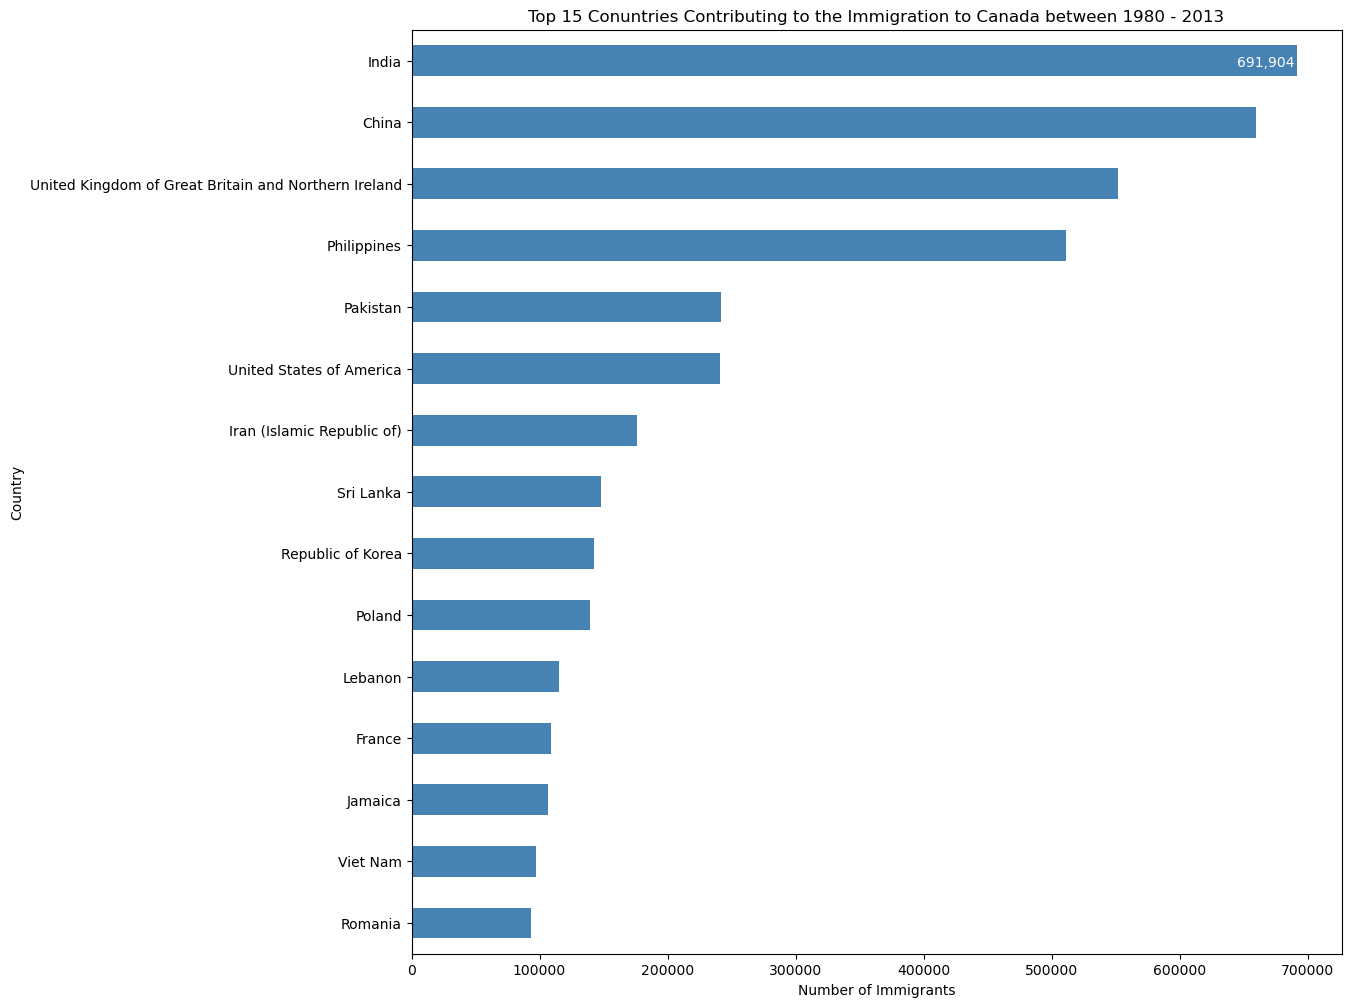

In [24]:
# generate plot
df_top15.plot(kind='barh', figsize=(12, 12), color='steelblue')
plt.xlabel('Number of Immigrants')
plt.title('Top 15 Conuntries Contributing to the Immigration to Canada between 1980 - 2013')

# annotate value labels to each country
for index, value in enumerate(df_top15): 
    label = format(int(value), ',') # format int with commas
    
# place text at the end of bar (subtracting 47000 from x, and 0.1 from y to make it fit within the bar)
plt.annotate(label, xy=(value - 47000, index - 0.10), color='white')

plt.show()